<h1 align="center">📊 Marketing Campaign Performance & A/B Testing Analysis</h1>
<h3 align="center">End-to-End Data Analytics & Business Intelligence Project</h3>

### STEP 1: DATA EXPLORATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [2]:
df.shape

(200000, 16)

In [3]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [5]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [6]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


### STEP 2: DATA CLEANING

In [ ]:
# Fixing Acquisition Cost datatype
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)

In [ ]:
# fixing datatype for Date
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Duration          200000 non-null  object        
 5   Channel_Used      200000 non-null  object        
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  object        
 10  Language          200000 non-null  object        
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [10]:
df.duplicated().sum()

np.int64(0)

### STEP 3: FEATURE ENGINEERING

In [11]:
#Click Through Rate: Measures how many people clicked
df['CTR'] = df['Clicks'] / df['Impressions']

In [12]:
# Conversion Efficiency: How effective clicks are converting
df['Conversion_Per_Click'] = df['Conversion_Rate'] / df['CTR']

In [13]:
# Cost Efficiency: How much return per cost
df['Cost_Efficiency'] = df['ROI'] / df['Acquisition_Cost']

In [14]:
df[['CTR', 'Conversion_Per_Click', 'Cost_Efficiency']].describe()

,CTR,Conversion_Per_Click,Cost_Efficiency
count,200000.000000,200000.000000,200000.000000
mean,0.140405,1.128333,0.000462
std,0.130881,1.309085,0.000258
min,0.010054,0.010101,0.000100
25%,0.058606,0.331716,0.000276
50%,0.099789,0.712453,0.000400
75%,0.169699,1.385582,0.000578
max,0.992024,14.551485,0.001592


## STEP 4: EDA

### 4.1 Campaign Performance

In [21]:
campaign_performance = df.groupby('Campaign_Type')[['CTR','Conversion_Per_Click','Cost_Efficiency']].mean().sort_values(by='Cost_Efficiency', ascending=False)
campaign_performance

,CTR,Conversion_Per_Click,Cost_Efficiency
Campaign_Type,,,
Search,0.139936,1.126241,0.000464
Display,0.141265,1.127826,0.000463
Influencer,0.140300,1.130493,0.000462
Email,0.139489,1.130859,0.000462
Social Media,0.141041,1.126243,0.000460


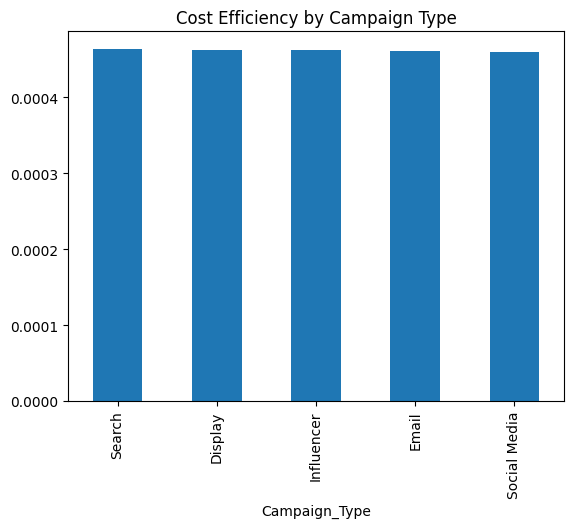

In [22]:
campaign_performance['Cost_Efficiency'].plot(kind='bar', title='Cost Efficiency by Campaign Type')
plt.show()

### 4.2 Channel Performance

In [25]:
channel_performance = df.groupby('Channel_Used')[['CTR','Conversion_Per_Click','Cost_Efficiency']].mean().sort_values(by='Cost_Efficiency', ascending=False)
channel_performance

,CTR,Conversion_Per_Click,Cost_Efficiency
Channel_Used,,,
Website,0.140971,1.120481,0.000464
Instagram,0.140037,1.127040,0.000462
Facebook,0.140499,1.126297,0.000462
YouTube,0.141196,1.127728,0.000462
Email,0.140543,1.124079,0.000461
Google Ads,0.139190,1.144336,0.000461


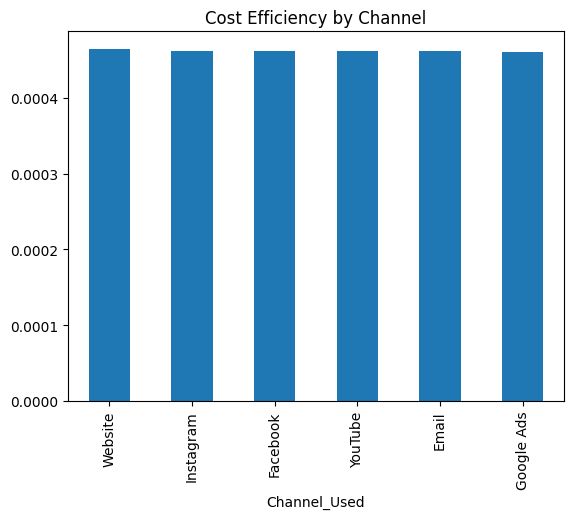

In [27]:
channel_performance['Cost_Efficiency'].plot(kind='bar', title='Cost Efficiency by Channel')
plt.show()

### 4.3 CTR Distribution

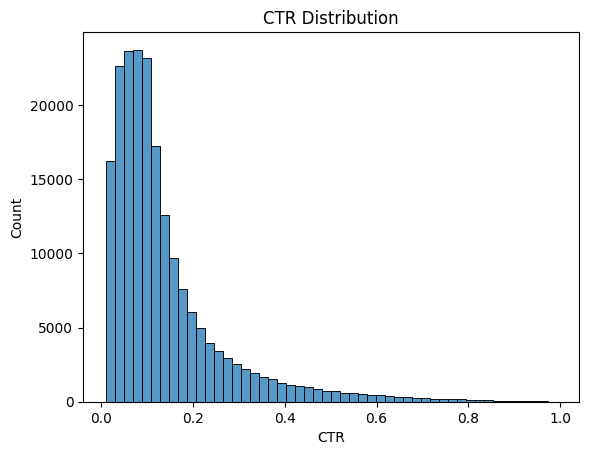

In [19]:
sns.histplot(df['CTR'], bins=50)
plt.title("CTR Distribution")
plt.show()

### 4.4 ROI vs Cost

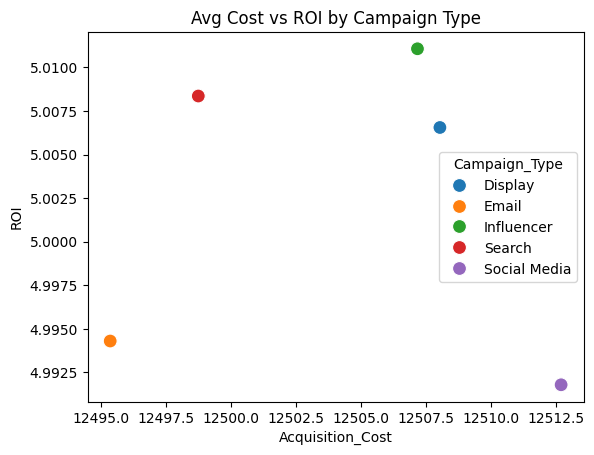

In [31]:
df_grouped = df.groupby('Campaign_Type')[['Acquisition_Cost','ROI']].mean().reset_index()

sns.scatterplot(data=df_grouped, x='Acquisition_Cost', y='ROI', hue='Campaign_Type', s=100)
plt.title("Avg Cost vs ROI by Campaign Type")
plt.show()

## STEP 5 A/B TESTING

## A/B Test 1: Email vs Social Media

In [36]:
group_A = df[df['Campaign_Type'] == 'Email']['Conversion_Per_Click']
group_B = df[df['Campaign_Type'] == 'Social Media']['Conversion_Per_Click']

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_A, group_B)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.49601998474903664
P-value: 0.6198816791455268


## A/B Test 2: Influencer vs Display

In [35]:
group_A = df[df['Campaign_Type'] == 'Influencer']['Conversion_Per_Click']
group_B = df[df['Campaign_Type'] == 'Display']['Conversion_Per_Click']

t_stat, p_value = ttest_ind(group_A, group_B)

print("Influencer mean:", group_A.mean())
print("Display mean:", group_B.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Influencer mean: 1.1304929932394208
Display mean: 1.1278262981099028
T-statistic: 0.28822395250994964
P-value: 0.7731760601945571


## A/B Test 3: Google Ads vs Facebook

In [37]:
group_A = df[df['Channel_Used'] == 'Google Ads']['Conversion_Per_Click']
group_B = df[df['Channel_Used'] == 'Facebook']['Conversion_Per_Click']

t_stat, p_value = ttest_ind(group_A, group_B)

print("Google Ads mean:", group_A.mean())
print("Facebook mean:", group_B.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Google Ads mean: 1.1443358869528613
Facebook mean: 1.1262966344166816
T-statistic: 1.7603048229328604
P-value: 0.07836075031489326
